# Getting started, with label (feature) uncertainties

This is a copy of `start.ipynb` that shows how to train a `CannonModel` while
accounting for **uncertainties on the training-set labels** (the "features"
that build the design matrix).

The standard Cannon treats labels as exact. If you pass
`training_set_label_err` -- a `(n_stars, n_labels)` array of 1-sigma errors
aligned to `LABEL_NAMES` -- then `train()` propagates those errors into the
per-pixel weights (errors-in-variables) and refines them with a few iteratively
reweighted least-squares passes. Stars whose labels are uncertain are
automatically down-weighted. Pass `None` (or omit it) to recover the exact
behaviour of `start.ipynb`.

The only changes from `start.ipynb` are flagged with **[label errors]** below.

In [1]:
# # --- environment setup (added for the JAX backend) ---
# import os, sys
# os.environ["JAX_PLATFORMS"] = "cpu"            # this machine's METAL backend is broken
# repo_root = os.path.abspath("..")              # notebooks/ -> AnniesLasso repo root
# if repo_root not in sys.path:
#     sys.path.insert(0, repo_root)              # ensure the edited working tree is imported

import jax
jax.config.update("jax_platform_name", "cuda")

import thecannon as tc
print("thecannon:", tc.__file__)

thecannon: /scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/thecannon/__init__.py


Evo_state; kepler: rgb: 1, heb=2

In [2]:
import os
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from thecannon import continuum

In [3]:
import pandas as pd
from pathlib import Path
SRC = Path("/home/100/mj8805/scr_mk27/")

In [4]:
spectra = pd.read_parquet(SRC / "bulge-ages-and-orbits/data/cleaned_ages.parquet")

In [5]:
spectra['EvoState'].value_counts()

EvoState
2.0    4585
1.0    4094
0.0     413
Name: count, dtype: int64

In [6]:
# spectra= spectra[spectra['EvoState'] == 2.0]

In [7]:
len(spectra)

18228

(array([1.1234e+04, 5.2750e+03, 1.3360e+03, 2.5900e+02, 7.6000e+01,
        2.0000e+01, 1.7000e+01, 6.0000e+00, 2.0000e+00, 3.0000e+00]),
 array([   0.        ,  287.97503662,  575.95007324,  863.92510986,
        1151.90014648, 1439.87524414, 1727.85021973, 2015.82519531,
        2303.80029297, 2591.77539062, 2879.75024414]),
 <BarContainer object of 10 artists>)

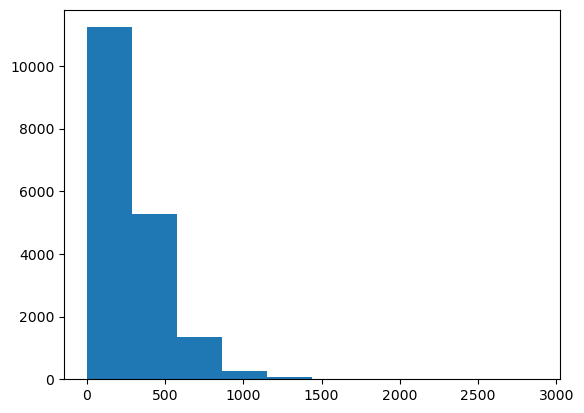

In [8]:
plt.hist(spectra['snr'])

In [9]:
spectra= spectra[spectra['snr'] > 200]
len(spectra)

10633

In [10]:
spectra['mg_fe'] = spectra['raw_mg_h'] - spectra['raw_fe_h']
spectra['ce_fe'] = spectra['raw_ce_h'] - spectra['raw_fe_h']
spectra['log_age_L'] = np.log10(spectra['age_L'])

In [11]:
labels = spectra[['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'ce_fe', 'log_age_L']]

# The wavelength/flux/ivar columns hold one array PER ROW. We need a single
# 1-D dispersion array and 2-D (n_stars, n_pixels) flux/ivar arrays -- NOT the
# raw pandas Series (a Series-of-arrays, which is what broke searchsorted).
def to_array(x):
    if isinstance(x, str):                       # stringified list (e.g. from CSV)
        return np.fromstring(x.strip("[] \n"), sep=",")
    return np.asarray(x, dtype=float)

dispersion = to_array(spectra['wavelength'].iloc[0])           # (n_pixels,)
flux = np.vstack([to_array(x) for x in spectra['flux']])       # (n_stars, n_pixels)
ivar = np.vstack([to_array(x) for x in spectra['ivar']])       # (n_stars, n_pixels)

# Sanity checks -- all must pass before normalizing.
assert dispersion.ndim == 1, dispersion.shape
assert flux.shape == ivar.shape == (len(spectra), dispersion.size)
assert np.all(np.diff(dispersion) > 0), "dispersion must be sorted ascending"
print(dispersion.shape, flux.shape, ivar.shape, dispersion.dtype)

(8575,) (10633, 8575) (10633, 8575) float64


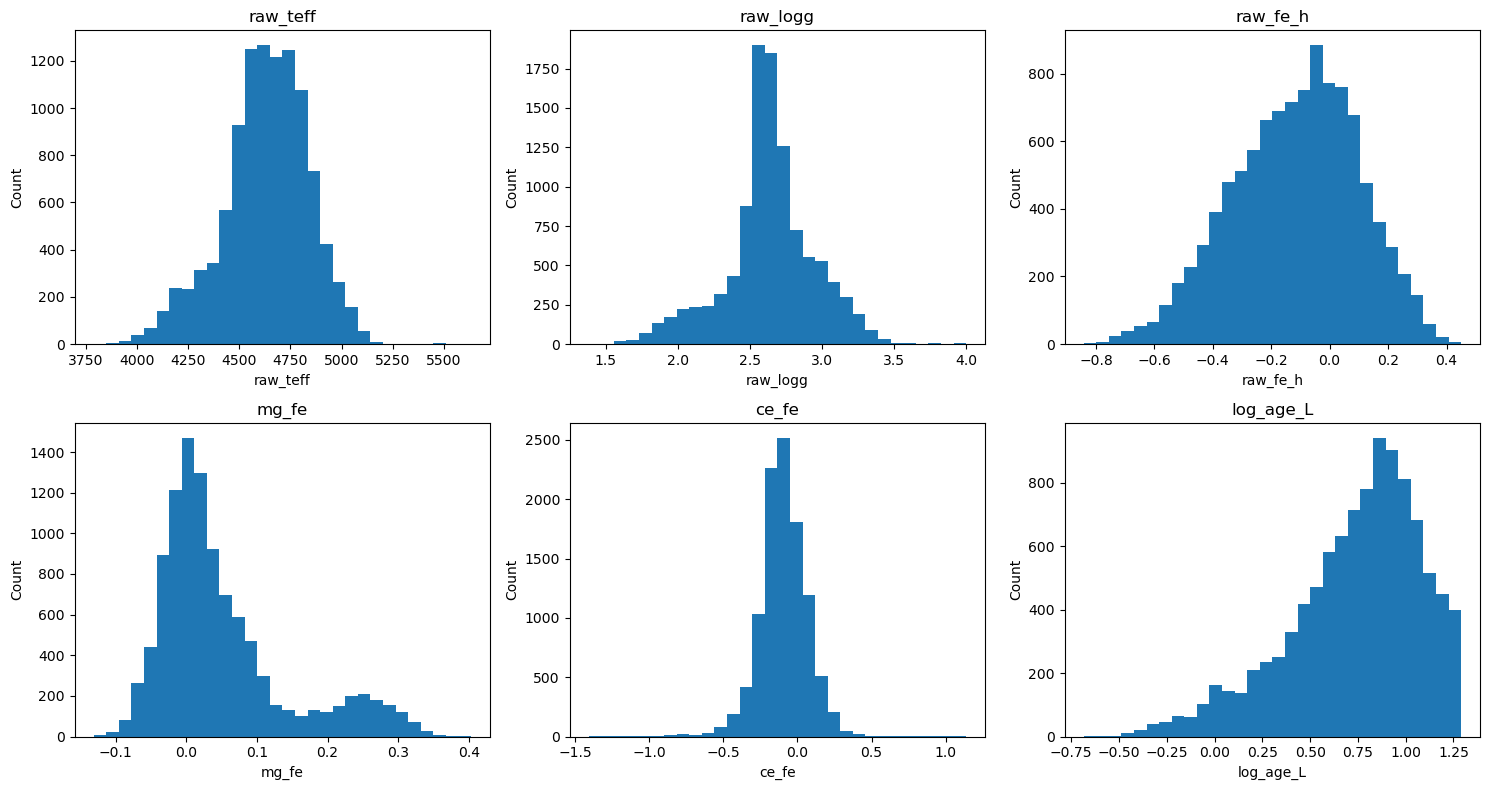

In [12]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(labels.columns)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(labels.columns):
    axes[i].hist(labels[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
# Integer continuum-pixel indices. Keep only those valid for this grid.
continuum_pixels = np.loadtxt(SRC / "bulge-ages-and-orbits/data/continuum.list", dtype=int, comments="#")
continuum_pixels = continuum_pixels[continuum_pixels < dispersion.size]
APOGEE_REGIONS = ([15090, 15822], [15823, 16451], [16452, 16971])

In [14]:
import jax.numpy as jnp
dispersion = jnp.array(dispersion)
flux = jnp.array(flux)
ivar = jnp.array(ivar)
continuum_pixels = jnp.array(continuum_pixels)
APOGEE_REGIONS = [jnp.array(r) for r in APOGEE_REGIONS]

E0609 22:31:56.428383 1266583 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 29.76GiB (31950225408 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0609 22:31:56.428897 1266583 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 26.78GiB (28755202048 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0609 22:31:56.429350 1266583 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 24.10GiB (25879681024 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0609 22:31:56.429799 1266583 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.69GiB (23291711488 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0609 22:31:56.430240 1266583 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.52GiB (20962539520 by

In [15]:
# NB: output is named `continuum_fit` so it doesn't shadow the imported
# `continuum` module (otherwise re-running this cell would fail).
normalized_flux, normalized_ivar, continuum_fit, metadata = continuum.normalize(
    dispersion,          # (n_pixels,) APOGEE wavelength grid
    flux,                # (n_stars, n_pixels)
    ivar,                # inverse variance, same shape
    continuum_pixels,
    L=1400, order=5,
    regions=APOGEE_REGIONS,
)

# Quick check: were the spectra already normalized, or did we just normalize them?
good = ivar > 0
print("median raw flux on good pixels:    ", np.median(flux[good]))
print("median normalized flux (should ~1):", np.median(normalized_flux[good]))

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

median raw flux on good pixels:     2994.933349609375
median normalized flux (should ~1): 0.9812272069561613


## Build, train, and test a CannonModel

Split into training / validation sets (dropping rows with non-finite labels),
fit a quadratic model on the training set, then predict labels for the
validation set and compare against the ASPCAP values.

In [16]:
list(labels.columns)

['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'ce_fe', 'log_age_L']

In [17]:
LABEL_NAMES = list(labels.columns)

# Drop stars with any non-finite label -- NaNs would break the training fit.
finite = np.isfinite(labels[LABEL_NAMES].values).all(axis=1)

# Reproducible split: ~10% train, ~10% validate (as in the old getting_started.py).
rng = np.random.RandomState(888)
q = rng.randint(0, 10, len(spectra))
train_set = finite & (q == 1)
validate_set = finite & (q == 0)
print(f"{train_set.sum()} training, {validate_set.sum()} validation stars "
      f"({(~finite).sum()} dropped for non-finite labels)")

967 training, 1006 validation stars (690 dropped for non-finite labels)


### [label errors] Assemble the per-label uncertainties

Build a `(n_stars, n_labels)` array of 1-sigma label errors, aligned to
`LABEL_NAMES`, that we will hand to the model below.

In [18]:
# [label errors] Build per-label 1-sigma uncertainties aligned to LABEL_NAMES.
#
# Plug in your real uncertainty columns here. ASPCAP-style tables usually carry
# per-label error columns; derived labels propagate from their components, e.g.
#   mg_fe = raw_mg_h - raw_fe_h  ->  sigma = sqrt(sigma_mg_h^2 + sigma_fe_h^2)
#
# We try a few common column-name conventions and fall back to representative
# 1-sigma floors when a column is missing, so the notebook runs end-to-end
# either way. Replace the fallbacks / mappings with whatever your table uses.

LABEL_NAMES = list(labels.columns)

# Representative 1-sigma floors (in each label's native units) used only when no
# error column is found. Tune these to your survey.
FALLBACK_SIGMA = {
    "raw_teff":  30.0,    # K
    "raw_logg":  0.05,    # dex
    "raw_fe_h":  0.02,    # dex
    "mg_fe":     0.03,    # dex
    "ce_fe":     0.05,    # dex
    "log_age_L": 0.10,    # dex (log10 age)
}

def _find_err_column(df, label):
    for cand in (f"{label}_err", f"e_{label}", f"{label}_e",
                 f"err_{label}", f"sigma_{label}"):
        if cand in df.columns:
            return cand
    return None

def label_sigma(df, label):
    col = _find_err_column(df, label)
    if col is not None:
        return np.asarray(df[col], dtype=float)
    # Error propagation for the derived labels, when the components are present.
    if label == "mg_fe" and {"raw_mg_h_err", "raw_fe_h_err"} <= set(df.columns):
        return np.hypot(df["raw_mg_h_err"], df["raw_fe_h_err"]).to_numpy()
    if label == "ce_fe" and {"raw_ce_h_err", "raw_fe_h_err"} <= set(df.columns):
        return np.hypot(df["raw_ce_h_err"], df["raw_fe_h_err"]).to_numpy()
    if label == "log_age_L" and "age_L_err" in df.columns:
        # d log10(age) = sigma_age / (age * ln 10)
        return (df["age_L_err"] / (df["age_L"] * np.log(10.0))).to_numpy()
    print(f"  [fallback] no error column for {label!r}; "
          f"using {FALLBACK_SIGMA[label]}")
    return np.full(len(df), FALLBACK_SIGMA[label], dtype=float)

label_err_full = np.column_stack([label_sigma(spectra, ln) for ln in LABEL_NAMES])

# Errors must be finite and strictly positive; clamp anything else to the floor.
floor = np.array([FALLBACK_SIGMA[ln] for ln in LABEL_NAMES])
bad = ~np.isfinite(label_err_full) | (label_err_full <= 0)
label_err_full = np.where(bad, floor, label_err_full)

print("label_err shape:", label_err_full.shape)
print("median 1-sigma per label:",
      dict(zip(LABEL_NAMES, np.round(np.median(label_err_full, axis=0), 4))))

  [fallback] no error column for 'raw_teff'; using 30.0
  [fallback] no error column for 'raw_logg'; using 0.05
  [fallback] no error column for 'raw_fe_h'; using 0.02
  [fallback] no error column for 'mg_fe'; using 0.03
  [fallback] no error column for 'ce_fe'; using 0.05
  [fallback] no error column for 'log_age_L'; using 0.1
label_err shape: (10633, 6)
median 1-sigma per label: {'raw_teff': np.float64(30.0), 'raw_logg': np.float64(0.05), 'raw_fe_h': np.float64(0.02), 'mg_fe': np.float64(0.03), 'ce_fe': np.float64(0.05), 'log_age_L': np.float64(0.1)}


In [19]:
# Quadratic (order=2) polynomial vectorizer in the labels.
vectorizer = tc.vectorizer.PolynomialVectorizer(label_names=LABEL_NAMES, order=2)

# [label errors] Pass `training_set_label_err`. With it set, `train()` runs the
# errors-in-variables path: it propagates the label uncertainties into the
# per-pixel weights and refines them with `n_irls` reweighting passes, so stars
# with uncertain labels are down-weighted. Drop this argument (or pass None) for
# the standard exact-label Cannon.
model = tc.CannonModel(
    labels[train_set],
    normalized_flux[train_set],
    normalized_ivar[train_set],
    vectorizer,
    dispersion=dispersion,
    regularization=1e-6,
    training_set_label_err=label_err_full[train_set])   # <-- the new bit

print(model)
print("label_err set:", model.training_set_label_err is not None,
      "| shape:", np.asarray(model.training_set_label_err).shape)

# Train (fits theta + scatter s2 at every pixel). `n_irls` (default 5) controls
# how many label-error reweighting passes are used; it is ignored when no label
# errors are set.
theta, s2, train_meta = model.train(n_irls=5)
print("trained:", model.is_trained, "| theta shape:", np.asarray(theta).shape)

TypeError: CannonModel._verify_training_data() got an unexpected keyword argument 'training_set_label_err'

In [ ]:
# Predict labels for the validation set (the "test" step). Returns
# (labels, covariance, metadata). Note: it's .test(), not .fit().
val_labels, val_cov, val_meta = model.test(
    normalized_flux[validate_set], normalized_ivar[validate_set])
val_labels = np.asarray(val_labels)
truth = labels[validate_set].values
print("predicted label array shape:", val_labels.shape)

In [ ]:
# One-to-one comparison of Cannon-predicted vs ASPCAP labels on the validation set.
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for i, (name, ax) in enumerate(zip(LABEL_NAMES, axes.ravel())):
    x, y = truth[:, i], val_labels[:, i]
    ax.scatter(x, y, facecolor="k", s=10)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    d = y - x
    ax.set_xlabel(f"{name} (ASPCAP)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={np.nanmean(d):+.3f}, scatter={np.nanstd(d):.3f}")
fig.tight_layout()

### [label errors] How much do the label errors change the fit?

Train an exact-label model on the same data (no `training_set_label_err`) and
compare the validation scatter per label. This retrains from scratch, so it
roughly doubles the runtime -- skip it if you only wanted the API.

In [ ]:
# Exact-label baseline (same data, no label_err) for comparison.
model_noerr = tc.CannonModel(
    labels[train_set],
    normalized_flux[train_set],
    normalized_ivar[train_set],
    vectorizer,
    dispersion=dispersion,
    regularization=1e-6)
model_noerr.train()

val_noerr, _, _ = model_noerr.test(
    normalized_flux[validate_set], normalized_ivar[validate_set])
val_noerr = np.asarray(val_noerr)

print(f"{'label':<12} {'scatter (exact)':>16} {'scatter (EIV)':>16}")
for i, name in enumerate(LABEL_NAMES):
    s_exact = np.nanstd(val_noerr[:, i]   - truth[:, i])
    s_eiv   = np.nanstd(val_labels[:, i] - truth[:, i])
    print(f"{name:<12} {s_exact:>16.4f} {s_eiv:>16.4f}")